# Resolución problema MMM a partir de su matriz QUBO

In [1]:
#pip install pulser pulser-simulation
from bloqade.analog import start, cast, load, save
import os
import matplotlib.pyplot as plt
from bokeh.io import output_notebook
from bloqade.analog.atom_arrangement import ListOfLocations, Square
from bloqade.analog import piecewise_linear, cast
from bloqade.analog.atom_arrangement import ListOfLocations, Lieb, Square, Chain, Honeycomb, Kagome, Triangular, Rectangular
import numpy as np
from IPython.display import display, HTML
from bokeh.io import output_notebook
output_notebook()

import matplotlib.pyplot as plt
import pulser
import pulser_simulation
from scipy.optimize import minimize
from scipy.spatial.distance import pdist, squareform
import matplotlib.colors as mcolors


c:\Users\j.pena.riosalido\Documents\Codigo_tfg\.venv\Lib\site-packages\bloqade\analog\__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


Loading BokehJS ...

# Definición de funciones para la resolución del grafo
1. `resolucion_clasica`: Obtiene la solución a lo bruto de forma clásica
2. `construir_geometria`: Establece la geometrías que codifica la matriz QUBO dada. Usa el algoritmo clásico Nelder-Mead
3. `resolver_qubo`: Emula el ordenador cuántico aportando la solución

In [2]:
# Obtenemos la solución clásica por fuerza bruta
def resolucion_clasica(Q_exacta, print_resultados = False):
    """
    Resuelve un problema QUBO por fuerza bruta (enumeración exhaustiva).

    Parámetros
    ----------
    Q       : array-like – Matriz QUBO.
    verbose : bool       – Si True, imprime las mejores soluciones.

    Retorna
    -------
    sort_zipped : list[(str, float)] – Todos los bitstrings ordenados por coste.
    """
    Q_exacta = np.array(Q_exacta)

    bitstrings = [np.binary_repr(i, len(Q_exacta)) for i in range(2 ** len(Q_exacta))]
    costs = []
    # this takes exponential time with the dimension of the QUBO
    for b in bitstrings:
        z = np.array(list(b), dtype=int)
        cost = z @ Q_exacta @ z
        costs.append(cost)
    zipped = zip(bitstrings, costs)
    sort_zipped = sorted(zipped, key=lambda x: x[1])

    if print_resultados:
        print(f"---Solución clásica: \n {sort_zipped[:6]} \n")

    return sort_zipped
# Ejecución de la función 
#sort_zipped = resolucion_clasica(Q_exacta)


# Determinamos la geometría de los átomos para Q
def construir_geometria(Q, seed=0, tol=1e-6, maxiter=200000, plot=False):
    """
    Optimiza las coordenadas atómicas para que las interacciones Rydberg
    reproduzcan la matriz QUBO, y construye la geometría de Bloqade.

    Parámetros
    ----------
    Q       : array-like – Matriz QUBO (simétrica).
    seed    : int        – Semilla para reproducibilidad.
    tol     : float      – Tolerancia del optimizador Nelder-Mead.
    maxiter : int        – Máximo de iteraciones.
    plot    : bool       – Si True, dibuja el registro Pulser y la geometría Bloqade.

    Retorna
    -------
    geometria : bloqade Program – Geometría lista para montar el programa.
    coords    : np.ndarray      – Coordenadas optimizadas (n×2).
    """
    Q = np.array(Q)
    device = pulser.DigitalAnalogDevice

    def evaluate_mapping(new_coords):
        new_coords = np.reshape(new_coords, (len(Q), 2))
        new_Q = squareform(device.interaction_coeff / pdist(new_coords) ** 6)
        return np.linalg.norm(new_Q - Q)

    np.random.seed(seed)
    x0 = np.random.random(len(Q) * 2)
    res = minimize(
        evaluate_mapping,
        x0,
        method="Nelder-Mead",
        tol=tol,
        options={"maxiter": maxiter, "maxfev": None},
    )

    coords = np.reshape(res.x, (len(Q), 2))

    if plot:
        # Visualización Pulser
        coord_dict = {f"q{i}": coord for i, coord in enumerate(coords)}
        reg = pulser.Register(coord_dict)
        reg.draw(
            blockade_radius=device.rydberg_blockade_radius(1),
            draw_graph=False,
            draw_half_radius=True,
        )
        print(f"Coordenadas optimizadas:\n{coords}")

    # Construcción Bloqade
    coordenadas = [tuple(pt) for pt in coords.tolist()]
    geometria = start.add_position(coordenadas)

    if plot:
        geometria.show()

    return geometria, coords
# Ejecución de la función 
#geometria, coords = construir_geometria(Q)


def resolver_qubo(Q, geometria, sort_zipped, A, B, C,
                    sweep_time=11.0, plot=False, n_shots=1000):
    """
    Ejecuta la simulación de átomos neutros para un problema QUBO dado.

    Parámetros
    ----------
    Q             : array-like  – Matriz QUBO.
    geometria     : Register     – Geometría de átomos (Bloqade).
    sort_zipped   : list[(str, float)] – Soluciones clásicas ordenadas (bitstring, energía).
    A, B, C       : float        – Coeficientes QUBO (solo para etiquetas).
    omega_max     : float        – Amplitud máxima de la frecuencia de Rabi.
    sweep_time    : float        – Tiempo de evolución adiabática [µs].
    plot          : bool         – Si True, muestra el histograma.
    n_shots       : int          – Número de disparos de la simulación.
    sweep_time    : float        – Tiempo de evolución adiabática [µs].
    plot          : bool         – Si True, muestra el histograma.

    Retorna
    -------
    prob_exito    : float        – Probabilidad de medir la solución correcta.
    counts_str    : dict         – {bitstring: conteos}.
    """
    # ── PASO 1: Detunings locales desde la diagonal de Q ──
    Q = np.array(Q)
    delta_local = -np.diag(Q)
    delta_end   = np.max(delta_local)
    escalas     = (delta_local / delta_end).tolist()

    # ── PASO 2: Parámetros de pulso ──
    omega_max = 0.9 * np.min(delta_local)
    sweep_time=11.0
    durations             = [0.8, sweep_time, 0.8]
    rabi_amplitude_values = [0.0, omega_max, omega_max, 0.0]
    rabi_detuning_values  = [-delta_end, -delta_end, delta_end, delta_end]

    # ── PASO 3: Simulación ──
    prog = (
        geometria
        .rydberg.rabi.amplitude.uniform.piecewise_linear(durations, rabi_amplitude_values)
        .detuning.scale(escalas).piecewise_linear(durations, rabi_detuning_values)
    )
    emu_prog = prog.bloqade.python().run(shots=n_shots)
    report   = emu_prog.report()
    if plot:
        report.show()

    # ── PASO 4: Análisis ──
    counts = report.counts()[0]
    counts_str = {
        "".join(str(b) for b in estado): n
        for estado, n in counts.items()
    }

    energia_minima   = sort_zipped[0][1]
    soluciones_validas = [b for b, e in sort_zipped if e == energia_minima]

    exitos     = sum(counts_str.get(s, 0) for s in soluciones_validas)
    prob_exito = exitos / n_shots

    # ── PASO 5: Resultados ──
    if plot:
        print(f"A={A}, B={B}, C={C}  →  P(éxito) = {prob_exito*100:.2f}%")
        print(f"  Soluciones válidas: {soluciones_validas}  (E = {energia_minima:.3f})")
        print(f"  Conteos solución:   {exitos} / {n_shots}")
        counts_ordenado = dict(sorted(counts_str.items(), key=lambda x: x[1], reverse=True))
        colores = ["r" if b in soluciones_validas else "steelblue" for b in counts_ordenado]
        plt.figure(figsize=(12, 5))
        plt.bar(counts_ordenado.keys(), counts_ordenado.values(), color=colores, width=0.5)
        plt.xlabel("Bitstrings")
        plt.ylabel("Conteos")
        plt.title(f"A={A}, B={B}, C={C}  →  P(éxito) = {prob_exito*100:.2f}%")
        plt.xticks(rotation=90, fontsize=7)
        plt.tight_layout()
        plt.show()

    return prob_exito, counts_str
# Ejecución de la función 
#prob, counts = resolver_qubo(Q, geometria, sort_zipped, A, B, C)

# Definición del grafo (matriz Q)
Distingo entre `Q` y `Q_exacta` porque la interacción entre aristas separadas por más de un nodo a veces altera la resolución del problema

### Grafo $P_4$

In [4]:
#Grafo P_4 (cadena de 4 nodos)

A_solucion=10
B_solucion=5
C_solucion=3

nombre_grafo = str("P4")

Q_func = lambda A, B, C: np.array(
    [[-2*B+C, A+2*B, 0      ],
     [0,      -3*B+C, A+2*B ],
     [0,       0,     -2*B+C]]
)


Q_exacta_func = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, B],
    [0,      -3*B+C, A+2*B],
    [0,       0,     -2*B+C]
])


### $P_5$

In [ ]:
A_solucion=50
B_solucion=0.8*A_solucion
C_solucion=0.5*A_solucion

nombre_grafo = str("P5")

Q_func = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0     ],
    [0,      -3*B+C, A+2*B, 0     ],
    [0,       0,    -3*B+C, A+2*B ],
    [0,       0,     0,    -2*B+C ]
])

Q_exacta_func = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0     ],
    [0,      -3*B+C, A+2*B, 0     ],
    [0,       0,    -3*B+C, A+2*B ],
    [0,       0,     0,    -2*B+C ]
])

### $P_6$

In [ ]:
A_solucion=10
B_solucion=5
C_solucion=3

nombre_grafo = str("P6  ")

Q_func = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0,      0     ],
    [0,      -3*B+C, A+2*B, 0,      0     ],
    [0,       0,    -3*B+C, A+2*B,  0     ],
    [0,       0,     0,    -3*B+C,  A+2*B ],
    [0,       0,     0,     0,     -2*B+C ]
])

Q_exacta_func = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0,      0     ],
    [0,      -3*B+C, A+2*B, 0,      0     ],
    [0,       0,    -3*B+C, A+2*B,  0     ],
    [0,       0,     0,    -3*B+C,  A+2*B ],
    [0,       0,     0,     0,     -2*B+C ]
])

### Grafo Y

In [3]:
#Grafo Y

A_solucion=50 # A partir de A =110, la simulación tarda mucho más tiempo
B_solucion=0.8*A_solucion
C_solucion=0.2*A_solucion

nombre_grafo = str("Y")

Q_func = lambda A, B, C: np.array([
    [-2*B+C,   A+2*B,   0,    0],
    [0,     -4*B+C,  A+2*B,   A+2*B],
    [0,     0,       -3*B+C,  A+2*B],
    [0,     0,       0,       -3*B+C]
])


Q_exacta_func = lambda A, B, C: np.array([
    [-2*B+C,   A+2*B,   B,    B],
    [0,     -4*B+C,  A+2*B,   A+2*B],
    [0,     0,       -3*B+C,  A+2*B],
    [0,     0,       0,       -3*B+C]
])


### Grafo $C_4$

In [9]:
A_solucion=50 # Falta comprobarlo
B_solucion=0.8*A_solucion
C_solucion=0.2*A_solucion

nombre_grafo = str("C_4")

Q_exacta_func = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, 2*B,   A+2*B],
    [0,      -3*B+C, A+2*B, 2*B  ],
    [0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,     -3*B+C]
])

Q_func = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, 0,     A+2*B],
    [0,      -3*B+C, A+2*B, 0   ],
    [0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,     -3*B+C]
])

### Grafo $C_5$

In [3]:
A_solucion=50 # Falta comprobarlo
B_solucion=0.8*A_solucion
C_solucion=0.2*A_solucion

nombre_grafo = str("C_5")

Q_exacta_func = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, B,      B,      A+2*B],
    [0,      -3*B+C, A+2*B, B,      B    ],
    [0,      0,      -3*B+C, A+2*B, B    ],
    [0,      0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,      0,      -3*B+C]
])

Q_func = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, 0,      0,      A+2*B],
    [0,      -3*B+C, A+2*B, 0,      0    ],
    [0,      0,      -3*B+C, A+2*B, 0    ],
    [0,      0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,      0,      -3*B+C]
])

### Grafo $C_6$

In [3]:
A_solucion=50 # Falta comprobarlo
B_solucion=0.8*A_solucion
C_solucion=0.2*A_solucion

nombre_grafo = str("C_6")

# Matriz exacta
Q_exacta_func = lambda A, B, C: np.array([
    [-3*B+C, A+2*B,  B,      0,      B,      A+2*B],
    [0,      -3*B+C, A+2*B,  B,      0,      B    ],
    [0,      0,      -3*B+C, A+2*B,  B,      0    ],
    [0,      0,      0,      -3*B+C, A+2*B,  B    ],
    [0,      0,      0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,      0,      0,      -3*B+C]
])

# En este caso no hace falta aproximar
Q_func = lambda A, B, C: np.array([
    [-3*B+C, A+2*B,  B,      0,      B,      A+2*B],
    [0,      -3*B+C, A+2*B,  B,      0,      B    ],
    [0,      0,      -3*B+C, A+2*B,  B,      0    ],
    [0,      0,      0,      -3*B+C, A+2*B,  B    ],
    [0,      0,      0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,      0,      0,      -3*B+C]
])



### Grafo $K_{1'3}$

In [44]:
A = A_solucion = 50
B = B_solucion = 0.8*A_solucion
C = C_solucion = 0.1*A_solucion

nombre_grafo = str("K_3")

Q_exacta_func = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, A+2*B],
    [0,      -3*B+C, A+2*B],
    [0,      0,      -3*B+C]
])

Q_func = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, A+2*B],
    [0,      -3*B+C, A+2*B],
    [0,      0,      -3*B+C]
])

### Grafo $K_{1'4}$ *(no es posible representarlo correctamente)*

In [21]:
Q_exacta_func = lambda A, B, C: np.array([
    [-4*B+C, A+2*B, A+2*B, A+2*B],
    [0,      -4*B+C, A+2*B, A+2*B],
    [0,      0,      -4*B+C, A+2*B],
    [0,      0,      0,      -4*B+C]
])

Q_func = lambda A, B, C: np.array([
    [-4*B+C, A+2*B, A+2*B, A+2*B],
    [0,      -4*B+C, A+2*B, A+2*B],
    [0,      0,      -4*B+C, A+2*B],
    [0,      0,      0,      -4*B+C]
])

# Resolución para 1 caso

---Solución clásica: 
 [('0101', np.float64(-150.0)), ('1010', np.float64(-150.0)), ('1001', np.float64(-110.0)), ('0010', np.float64(-95.0)), ('0100', np.float64(-95.0)), ('1011', np.float64(-75.0))] 



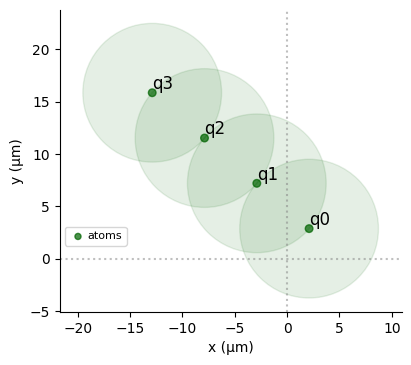

Coordenadas optimizadas:
[[  2.10101026   2.86032136]
 [ -2.89519912   7.18791719]
 [ -7.89150605  11.51560582]
 [-12.88771663  15.84320026]]


-12887716.63162327 2101010.256992695 2860321.359573568 15843200.255671427


A=50, B=40.0, C=25.0  →  P(éxito) = 89.19%
  Soluciones válidas: ['0101', '1010']  (E = -150.000)
  Conteos solución:   8919 / 10000


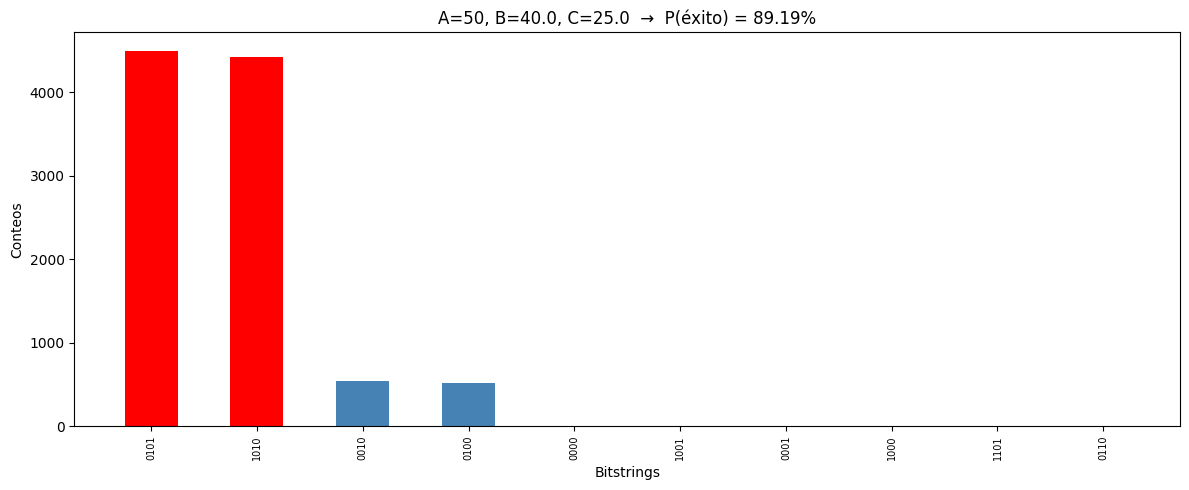

In [6]:
A = A_solucion = 50
B = B_solucion = 0.8*A_solucion
C = C_solucion = 0.5*A_solucion

sort_zipped = resolucion_clasica(Q_exacta = Q_exacta_func(A_solucion, B_solucion, C_solucion), print_resultados=True)

Q       = Q_func(A, B, C)
geometria, _       = construir_geometria(Q, plot=True)
prob, _            = resolver_qubo(Q, geometria, sort_zipped, A, B, C, plot=True, n_shots=10000)

A_values = [A]
B_values = [B]
C_values = [C]



# Heatmap variación B,C

---Solución clásica: 
 [('0101', np.float64(-150.0)), ('1010', np.float64(-150.0)), ('1001', np.float64(-110.0)), ('0010', np.float64(-95.0)), ('0100', np.float64(-95.0)), ('1011', np.float64(-75.0))] 



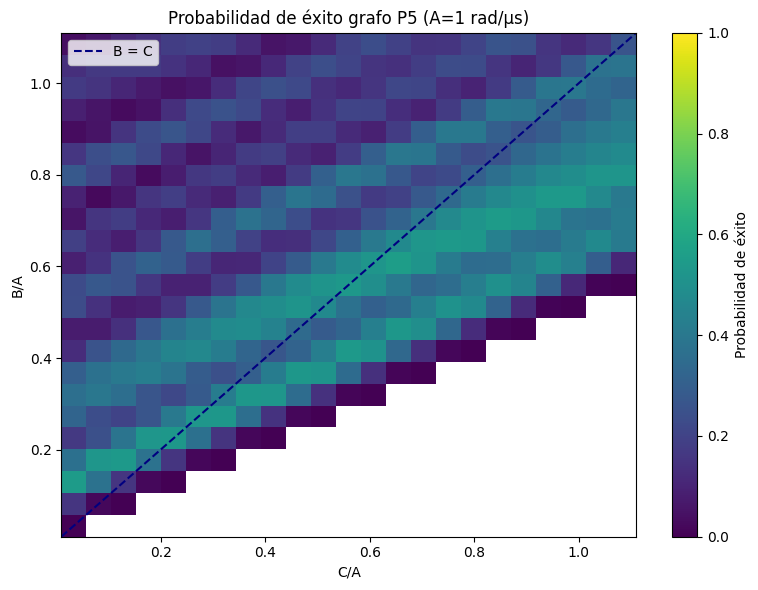

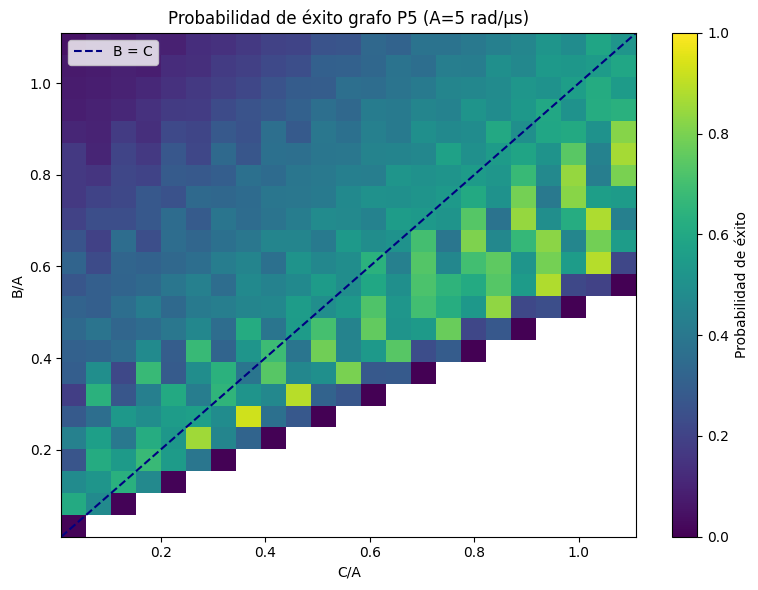

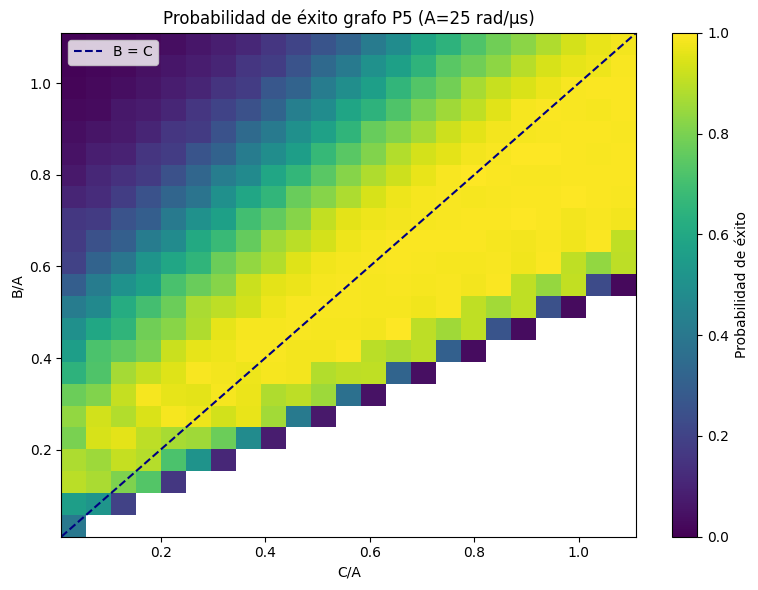

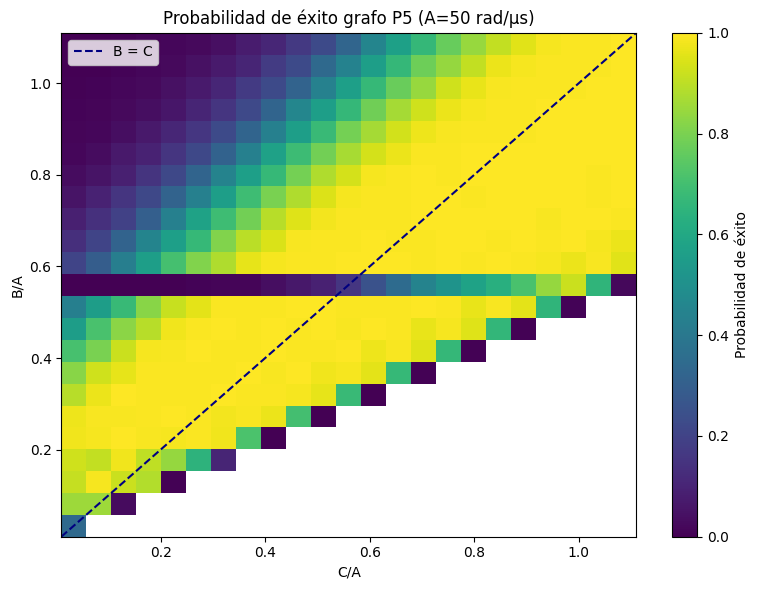

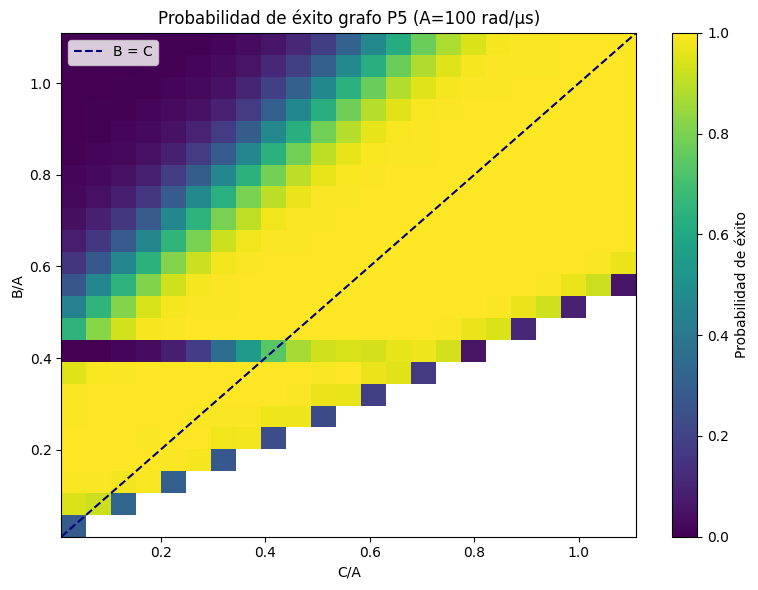

KeyboardInterrupt: 

In [8]:
# Obtención de la solución de forma clásica. Es importante asegurarse que para estos valores la solución es correcta


A = A_solucion #10
B = B_solucion #0.5*A
C = C_solucion #0.8*B
sort_zipped = resolucion_clasica(Q_exacta = Q_exacta_func(A_solucion, B_solucion, C_solucion), print_resultados=True)



A_values = [1, 5, 25, 50, 100, 150]
##A_values = np.arange(5, 5.1, 0.5)


resultados = {}
for A in A_values:
    B_values = np.arange(0.01*A, 1.12*A, 0.05*A)
    C_values = np.arange(0.01*A, 1.12*A, 0.05*A)

    for B in B_values:
        for C in C_values:
            Q = Q_func(A, B, C)
            diag = -np.diag(Q)
            
            # Filtro para evitar casos no físicos (detuning negativo)
            if np.any(diag <= 0):
                resultados[(A, B, C)] = np.nan  # o 0.0
                continue

            geometria, _ = construir_geometria(Q, plot=False)
            prob, _ = resolver_qubo(Q, geometria, sort_zipped, A, B, C, plot=False, n_shots=1000)
            resultados[(A, B, C)] = prob



    B_unique = sorted(set(k[1] for k in resultados if k[0] == A))
    C_unique = sorted(set(k[2] for k in resultados if k[0] == A))
    malla = np.array([[resultados[(A, B, C)] for C in C_unique] for B in B_unique])
    malla_masked = np.ma.masked_invalid(malla)

    # Normalizar: B/A y C/B_ref (donde B_ref = 0.5*A como en la definición inicial)
    B_norm = [b / A for b in B_unique]
    C_norm = [c / A for c in C_unique] 

    plt.figure(figsize=(8, 6))
    plt.imshow(malla_masked, origin='lower', aspect='auto',
               extent=[C_norm[0], C_norm[-1], B_norm[0], B_norm[-1]], #Esto define los límites de los ejes 
               vmin=0, vmax=1)
    plt.colorbar(label='Probabilidad de éxito')
    plt.xlabel('C/A')
    plt.ylabel('B/A')
    plt.title(f'Probabilidad de éxito grafo {nombre_grafo} (A={A} rad/µs)')

    # Línea B = C (en unidades normalizadas B/A = C/A)
    x_line = np.linspace(C_norm[0], C_norm[-1], 100)
    plt.plot(x_line, x_line, color='navy', linestyle='--', linewidth=1.5, label='B = C')
    plt.legend()
    #plt.savefig(f"mapa_exito_{nombre_grafo} A_{A:.1f}.png")

    plt.tight_layout()
    plt.show()